# 14 · Resumen explicado: del LSTM de 2025 al LSTM multianual (2020–2026)

Este libro **cuenta toda la historia con gráficas**: qué problema atacamos, qué hacía
el detector cuando sólo teníamos 2025, qué cambió al tener siete años, cómo aprendió,
cómo se calibró y cómo le fue contra los ataques.

- **No entrena, no recalibra y no cambia ningún resultado.** Sólo lee lo que ya está
  guardado (notebooks 07, 09, 10–13).
- Cada sección tiene un recuadro **«Antes (sólo 2025)»** frente a **«Ahora (2020–2026)»**.
- Todos los números del multianual vienen de los modelos de
  `results/lstm_v4_multianual_v1/estaciones/` (entrenados el 2026-10-03, cargados de
  disco). Los de 2025 vienen de `results/` y `results/multiestacion_v4_p95_2025/`.
- Si un término no te queda claro, la sección 0 del notebook 12 lo explica desde cero.

**Índice**

1. El problema: voltear un bit
2. Antes y ahora: cómo se repartieron los datos
3. Los datos de siete años
4. Qué ve el modelo para estimar una hora
5. Cómo aprendió (épocas, error, sobreajuste)
6. Calibración: el umbral de alerta
7. ¿El LSTM sirve más que el perfil?
8. Sin ataques: falsas alarmas en años nuevos
9. Por qué unos bits se detectan y otros no
10. Resultados contra ataques, antes y ahora
11. Daño que se escapa: región crítica observada
12. Las estaciones sin detector
13. Resumen final

**Revisión de cierre — 2026-10-04.** Este resumen distingue resultados observados
de explicaciones aún no comprobadas. Se corrigieron textos y títulos, sin cambiar
modelos, umbrales ni tablas experimentales. La ilustración de la sección 9 utiliza
ahora el signo real del flip, no un signo sorteado. Las cifras de clasificación
de la sección 10 son del **grupo principal**; el barrido de daño incluye todos
los objetivos evaluables y conserva aparte las oportunidades sin evaluación.
Las referencias anteriores son contexto histórico, no una comparación controlada.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
get_ipython().run_line_magic('matplotlib', 'inline')  # Conservar las figuras dentro del notebook.

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')
from src.detect import multianual as m
from src.detect import entrenamiento_multianual as em
from src.detect import ataques_multianual as at

SAL = RAIZ / 'results/lstm_v4_multianual_v1'
EST = SAL / 'estaciones'
R25 = RAIZ / 'results/multiestacion_v4_p95_2025'
IMG = RAIZ / 'docs/img/lstm_v4_multianual_v1/resumen'
IMG.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 200)

# Estilo: paleta categórica validada (sólo los 3 primeros espacios para años), gris neutro
# para referencias, rojo reservado al umbral de 155 ppb, líneas finas y rejilla tenue.
AZUL, NARANJA, AQUA, AMARILLO = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
TINTA, TINTA2, GRIS, CRITICO = '#0b0b0b', '#52514e', '#9a9893', '#e34948'
COLOR_ANIO = {2024: AZUL, 2025: NARANJA, 2026: AQUA}
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'savefig.facecolor': '#fcfcfb',
    'axes.edgecolor': GRIS, 'axes.labelcolor': TINTA2, 'xtick.color': TINTA2, 'ytick.color': TINTA2,
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'lines.linewidth': 2,
    'lines.markersize': 6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})
def guardar(fig, nombre):
    fig.savefig(IMG / f'{nombre}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [2]:
# Sólo lectura: si faltan predicciones, regenerarlas explícitamente en el notebook 13.
ctx = em.contexto(RAIZ)
pred = at.cargar_predicciones(EST)  # Sin ctx: este resumen no regenera artefactos.
cob = pd.read_csv(SAL / 'cobertura_etapas.csv')
CLASES = cob.drop_duplicates('objetivo').set_index('objetivo')['clasificacion']
estado = pd.read_csv(SAL / 'estado_objetivos.csv')
limpias = pd.read_csv(SAL / 'metricas_limpias.csv')
pareada = pd.read_csv(SAL / 'metricas_pareadas_agregadas.csv')
dias = pd.read_csv(SAL / 'resumen_dano_dias.csv')
geo = pd.read_csv(RAIZ / 'results/inventario_multianual/estaciones_geografia.csv', index_col=0)
print('Objetivos entrenados:', int(estado.entrenado.sum()), '| filas de predicción:', len(pred))

Objetivos entrenados: 31 | filas de predicción: 533649


## 1. El problema: voltear un bit

En el experimento, cada lectura RAMA se codifica como un número entero dentro de
un payload LoRaWAN simulado. No se afirma que las estaciones reales de RAMA envíen
sus mediciones por LoRaWAN. En binario, las casillas tienen pesos 1, 2, 4, 8, 16,
32, 64 y 128: el número es la suma de los pesos de las casillas en 1.

El cifrado usado tiene la propiedad de maleabilidad: modificar una posición del
texto cifrado modifica la misma posición del texto descifrado, sin conocer la clave.
El escenario presupone acceso a un segmento donde esa alteración no es rechazada
por la verificación de integridad; no implica que cualquier cambio por radio sea aceptado.

Voltear el bit k suma 2^k si estaba en 0 y lo resta si estaba en 1. El atacante
ciego desconoce ese estado: **no significa que el signo se sortee independientemente**.

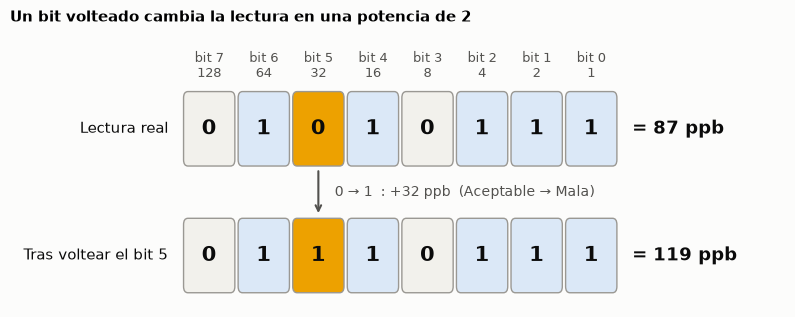

In [3]:
def dibujar_binario(ax, valor, y, resaltar=None, titulo=''):
    bits = [(valor >> k) & 1 for k in range(7, -1, -1)]
    for i, b in enumerate(bits):
        k = 7 - i
        color = AMARILLO if k == resaltar else ('#dbe8f7' if b else '#f2f1ec')
        ax.add_patch(mpatches.FancyBboxPatch((i, y), 0.9, 0.9, boxstyle='round,pad=0.02,rounding_size=0.08',
                                             fc=color, ec=GRIS, lw=1))
        ax.text(i + 0.45, y + 0.45, str(b), ha='center', va='center', fontsize=15, color=TINTA, weight='bold')
    ax.text(-0.3, y + 0.45, titulo, ha='right', va='center', fontsize=11, color=TINTA)
    ax.text(8.2, y + 0.45, f'= {valor} ppb', ha='left', va='center', fontsize=13, color=TINTA, weight='bold')

fig, ax = plt.subplots(figsize=(10, 3.6))
for i, k in enumerate(range(7, -1, -1)):
    ax.text(i + 0.45, 3.25, f'bit {k}\n{2**k}', ha='center', va='center', fontsize=9, color=TINTA2)
dibujar_binario(ax, 87, 2.0, resaltar=5, titulo='Lectura real')
dibujar_binario(ax, 87 ^ 32, 0.4, resaltar=5, titulo='Tras voltear el bit 5')
ax.annotate('', xy=(2.45, 1.35), xytext=(2.45, 1.95), arrowprops=dict(arrowstyle='->', color=TINTA2, lw=1.5))
ax.text(2.75, 1.65, '0 → 1  : +32 ppb  (Aceptable → Mala)', va='center', fontsize=10, color=TINTA2)
ax.set_xlim(-3.2, 11); ax.set_ylim(0.2, 3.7); ax.axis('off')
ax.set_title('Un bit volteado cambia la lectura en una potencia de 2', loc='left')
guardar(fig, '01_bit_flip')

**¿Por qué importa?** 87 ppb está en la banda *Aceptable* de la NOM-172; 119 ppb está en
*Mala*. Con un solo bit el atacante cambia lo que se le comunica a la población, o puede
fabricar o esconder una **excedencia de 155 ppb**, que es el umbral de contingencia. El
detector tiene que notar que el número recibido no es creíble.

## 2. Antes y ahora: cómo se repartieron los datos

Para saber si un detector funciona hay que probarlo con datos que **no vio** al
aprender. Por eso los datos se reparten en etapas:

- **Entrenamiento:** el modelo aprende con estos datos (ajusta sus pesos).
- **Validación:** sirve para decidir cuándo dejar de entrenar, sin aprender de ellos.
- **Calibración:** sirve para fijar el umbral de alerta, sin aprender de ellos.
- **Prueba:** el examen final; no se usa para decidir nada.

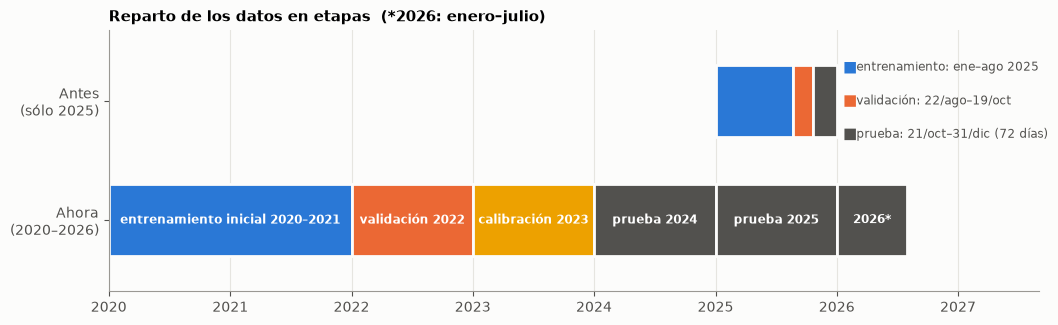

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.4))
T = pd.Timestamp
def barra(y, ini, fin, color, texto, alto=0.6):
    i, f = T(ini), T(fin)
    ax.barh(y, f - i, left=i, height=alto, color=color, edgecolor='#fcfcfb', linewidth=2)
    ax.text(i + (f - i) / 2, y, texto, ha='center', va='center', fontsize=8.5, color='white', weight='bold')

# Antes: sólo 2025
barra(1, '2025-01-01', '2025-08-22', AZUL, '')
barra(1, '2025-08-22', '2025-10-20', NARANJA, '')
barra(1, '2025-10-21', '2026-01-01', TINTA2, '')
for yy, color, txt in [(1.28, AZUL, 'entrenamiento: ene–ago 2025'), (1.0, NARANJA, 'validación: 22/ago–19/oct'),
                       (0.72, TINTA2, 'prueba: 21/oct–31/dic (72 días)')]:
    ax.text(T('2026-01-20'), yy, '■', color=color, va='center', fontsize=11)
    ax.text(T('2026-03-01'), yy, txt, color=TINTA2, va='center', fontsize=8.5)
# Ahora: 2020-2026
barra(0, '2020-01-01', '2022-01-01', AZUL, 'entrenamiento inicial 2020–2021')
barra(0, '2022-01-01', '2023-01-01', NARANJA, 'validación 2022')
barra(0, '2023-01-01', '2024-01-01', AMARILLO, 'calibración 2023')
barra(0, '2024-01-01', '2025-01-01', TINTA2, 'prueba 2024')
barra(0, '2025-01-01', '2026-01-01', TINTA2, 'prueba 2025')
barra(0, '2026-01-01', '2026-08-01', TINTA2, '2026*')
ax.set_yticks([1, 0], ['Antes\n(sólo 2025)', 'Ahora\n(2020–2026)'])
ax.set_ylim(-0.6, 1.6); ax.set_xlim(T('2020-01-01'), T('2027-09-01')); ax.grid(axis='y', visible=False)
ax.set_title('Reparto de los datos en etapas  (*2026: enero–julio)', loc='left')
guardar(fig, '02_reparto_etapas')

| | Antes (referencias de 2025) | Ahora (multianual) |
|---|---|---|
| Datos disponibles | 1 año, 8 760 horas | 2020–julio de 2026, 57 696 horas |
| Separación | 80/20 cronológico; validación dentro del ajuste | ajuste inicial 2020–21, validación 2022, ajuste definitivo 2020–22 |
| Umbral | p95 de entrenamiento por estación; piloto CCA con operativo 22.6 ppb | p95 propio por estación sobre calibración limpia 2023 |
| Prueba de red | 21/oct–31/dic: 72 días, ningún máximo diario ≥155 | 2024 y 2025 completos; enero–julio de 2026; 32 días ≥155 en total |
| Modelos guardados | 27 modelos de red, además de la referencia piloto CCA | 31 modelos: 30 evaluables en 2024, 31 en 2025 y 28 en 2026 parcial |

Ahora la prueba incluye periodos de ozono alto y excedencias observadas. Eso permite
medir ocultamientos que el test anterior no podía medir. **No demuestra por sí solo
que añadir años haya mejorado al detector**: también cambiaron calibración, modelo,
estaciones evaluables y periodo de prueba. 2025 ya se había explorado en el proyecto.

## 3. Los datos de siete años

La línea es la lectura más alta del día en toda la red de 33 estaciones. La franja gris
de 2025 es el periodo de prueba que usábamos antes: se ve que cae justo donde el ozono
es bajo.

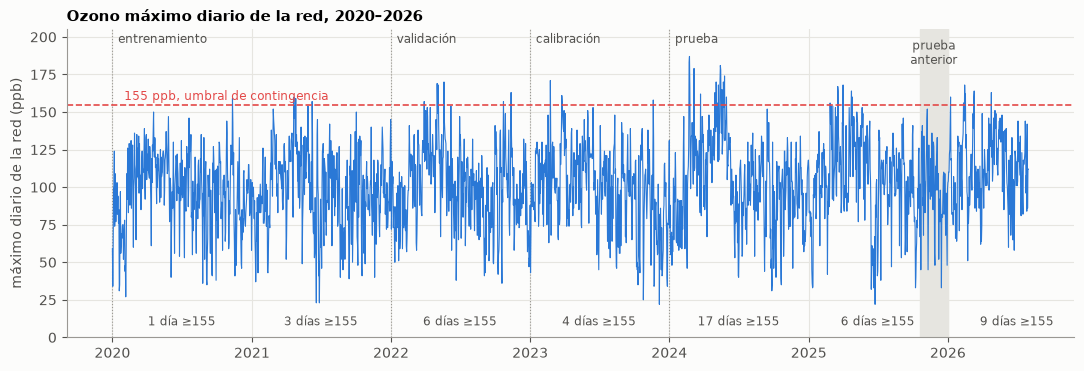

In [5]:
diario = ctx['valores'].max(axis=1).resample('D').max()
fig, ax = plt.subplots(figsize=(13, 4))
ax.axvspan(T('2025-10-21'), T('2025-12-31'), color='#e6e5e0', zorder=0)
ax.text(T('2025-11-25'), 182, 'prueba\nanterior', ha='center', fontsize=8.5, color=TINTA2)
for ini, fin, txt in [('2020-01-01', '2022-01-01', 'entrenamiento'), ('2022-01-01', '2023-01-01', 'validación'),
                      ('2023-01-01', '2024-01-01', 'calibración'), ('2024-01-01', '2026-08-01', 'prueba')]:
    ax.axvline(T(ini), color=GRIS, lw=0.8, ls=':')
    ax.text(T(ini) + pd.Timedelta(days=15), 196, txt, fontsize=8.5, color=TINTA2)
ax.plot(diario.index, diario, color=AZUL, lw=0.8)
ax.axhline(155, color=CRITICO, lw=1.2, ls='--')
ax.text(T('2020-02-01'), 158, '155 ppb, umbral de contingencia', color=CRITICO, fontsize=8.5)
for anio in range(2020, 2027):
    n = int((diario[str(anio)] >= 155).sum())
    ax.text(T(f'{anio}-07-01'), 8, f'{n} día{"s" if n != 1 else ""} ≥155', ha='center', fontsize=8.5, color=TINTA2)
ax.set_ylim(0, 205); ax.set_ylabel('máximo diario de la red (ppb)')
ax.set_title('Ozono máximo diario de la red, 2020–2026', loc='left')
guardar(fig, '03_maximo_diario')

Lecciones del inventario (notebook 10):

- El centinela de celdas faltantes es `-99`; además, en 2024 faltan dos renglones
  horarios completos. Se conservan como horas ausentes en la rejilla, sin comprimirla.
- XAL no tiene datos de ajuste en 2020–2022; HGM no tiene validación en 2022.
  Ambas quedan sin detector propio bajo este protocolo. XAL permanece como canal
  inactivo; HGM sí puede aportar datos como entrada cuando están disponibles.
- ACO tiene modelo guardado, pero no observaciones en 2024: no genera escenarios
  de ataque ese año. No es una tercera estación sin detector.
- En 2024 hay 17 días con alguna lectura ≥155 ppb: son **días con excedencia
  observada**, no un conteo de contingencias declaradas oficialmente.

## 4. Qué ve el modelo para estimar una hora

**Esto no cambió entre 2025 y ahora: es el mismo V4.** Para estimar la estación objetivo
a la hora t, el modelo recibe una **ventana**: las 24 horas anteriores de las otras 32
estaciones. Cada hora trae 66 números:

- 32 lecturas de las vecinas, **normalizadas** (se les resta su promedio y se dividen
  entre su variación típica, para que todas queden en escala parecida);
- 32 **máscaras**: 1 si hubo dato, 0 si faltó;
- 2 números con la **hora del día** en forma de círculo (seno y coseno), para que las
  23:00 y las 00:00 queden juntas.

Además está el **perfil adaptativo**: el promedio de la propia estación a esa misma hora
en los 14 días anteriores. El modelo **no** adivina el ozono completo: adivina **cuánto
se va a alejar del perfil**. La predicción final es `perfil + corrección`.

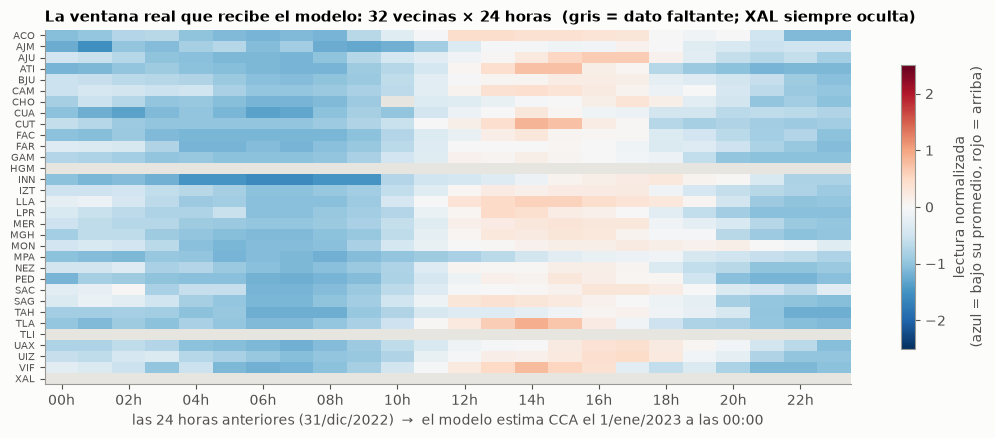

In [6]:
X = pd.read_csv(SAL / 'ejemplos_etapas/calibracion_20230101_00_entrada_24x66.csv', index_col=0, parse_dates=True)
val = X[[c for c in X.columns if c.endswith('_valor')]]
msk = X[[c for c in X.columns if c.endswith('_mascara')]].to_numpy()
mat = np.where(msk == 1, val.to_numpy(), np.nan)
fig, ax = plt.subplots(figsize=(13, 4.6))
cm = plt.get_cmap('RdBu_r').copy(); cm.set_bad('#e6e5e0')
im = ax.imshow(mat.T, aspect='auto', cmap=cm, vmin=-2.5, vmax=2.5)
ax.set_yticks(range(val.shape[1]), [c.replace('_valor', '') for c in val.columns], fontsize=7)
ax.set_xticks(range(0, 24, 2), [f'{h:02d}h' for h in X.index.hour[::2]])
ax.set_xlabel('las 24 horas anteriores (31/dic/2022)  →  el modelo estima CCA el 1/ene/2023 a las 00:00')
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8); cb.set_label('lectura normalizada\n(azul = bajo su promedio, rojo = arriba)')
ax.set_title('La ventana real que recibe el modelo: 32 vecinas × 24 horas  (gris = dato faltante; XAL siempre oculta)', loc='left')
guardar(fig, '04_ventana')

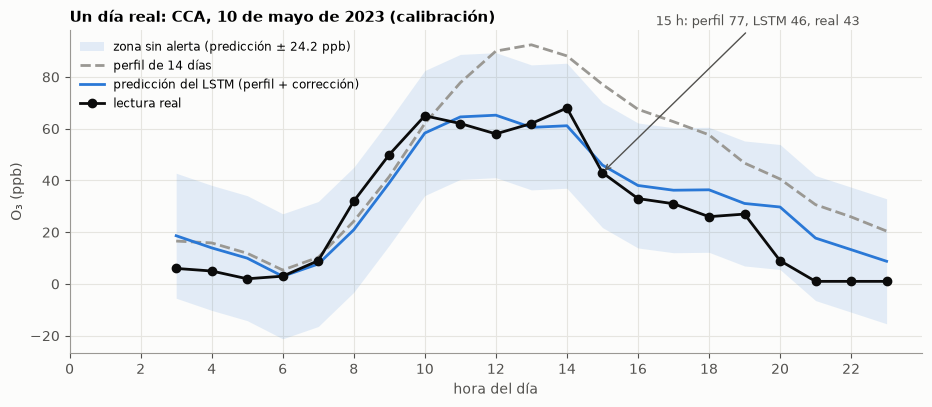

In [7]:
cal = pd.read_csv(EST / 'CCA/calibracion_2023.csv.gz', parse_dates=['timestamp'])
umbral_cca = float((EST / 'CCA/umbral_p95_cal2023.txt').read_text())
dia = cal[cal.timestamp.dt.date == pd.Timestamp('2023-05-10').date()]
fig, ax = plt.subplots(figsize=(11, 4.2))
h = dia.timestamp.dt.hour
ax.fill_between(h, dia.predicho_ppb - umbral_cca, dia.predicho_ppb + umbral_cca, color=AZUL, alpha=0.12, lw=0,
                label=f'zona sin alerta (predicción ± {umbral_cca:.1f} ppb)')
ax.plot(h, dia.base_ppb, color=GRIS, ls='--', label='perfil de 14 días')
ax.plot(h, dia.predicho_ppb, color=AZUL, label='predicción del LSTM (perfil + corrección)')
ax.plot(h, dia.original_ppb, color=TINTA, marker='o', label='lectura real')
r15 = dia[h == 15].iloc[0]
ax.annotate(f'15 h: perfil {r15.base_ppb:.0f}, LSTM {r15.predicho_ppb:.0f}, real {r15.original_ppb:.0f}',
            xy=(15, r15.original_ppb), xytext=(16.5, 100), fontsize=9, color=TINTA2,
            arrowprops=dict(arrowstyle='->', color=TINTA2))
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('hora del día'); ax.set_ylabel('O₃ (ppb)')
ax.legend(fontsize=8.5, loc='upper left')
ax.set_title('Un día real: CCA, 10 de mayo de 2023 (calibración)', loc='left')
guardar(fig, '05_dia_ejemplo')

**Cómo leer la gráfica:** ese día, la corrección aprendida aproxima la predicción
(azul) a la lectura original (negro) más que el perfil (gris). El modelo utiliza
el contexto de otras estaciones, pero esta figura no demuestra cuáles aportaron
esa corrección: eso requiere el análisis espacial pendiente.

Dentro de la franja no hay alerta; fuera sí. Un ataque puede sacar una lectura
de la franja o acercarla a la predicción. Por eso el efecto no depende sólo del
tamaño del desplazamiento, sino también del error original y del signo del flip.

## 5. Cómo aprendió

**Analogía:** el modelo es un estudiante con un cuaderno de ejercicios resueltos (los
ejemplos de 2020–2021). Una **época** es una pasada completa por el cuaderno. Después
de cada época presenta un **examen con ejercicios que no vio** (2022).

El **error** se mide como el promedio de los errores al cuadrado (ppb²); aquí lo
mostramos ya con **raíz cuadrada**, en ppb, para que se lea como «se equivoca unos X ppb».

| | Antes (sólo 2025) | Ahora |
|---|---|---|
| Examen para decidir cuándo parar | último 20 % del entrenamiento (ago–oct 2025) | 2022 completo |
| Modelo final | el mismo que se entrenó (30 épocas en CCA) | uno **nuevo**, entrenado E épocas con 2020–2022 |

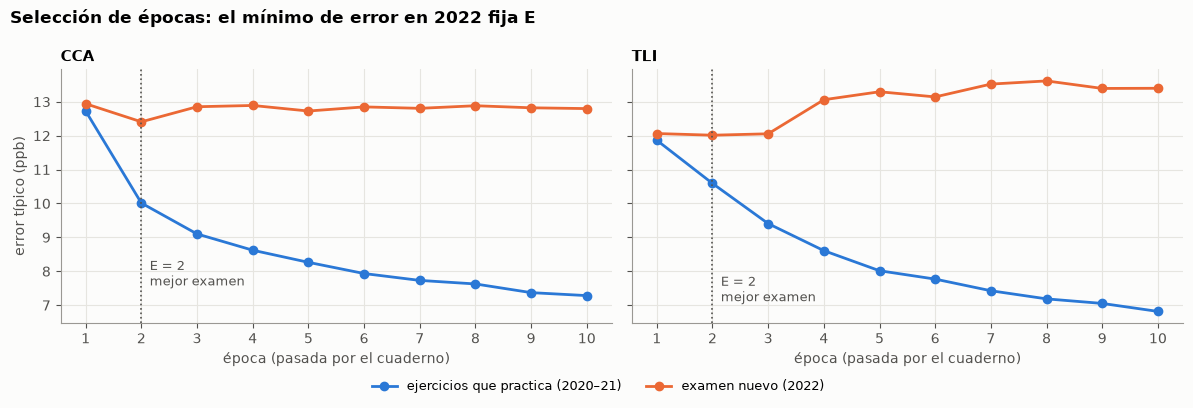

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, obj in zip(axes, ['CCA', 'TLI']):
    hs = pd.read_csv(EST / obj / 'seleccion/historia_seleccion.csv', index_col=0)
    E = json.loads((EST / obj / 'configuracion.json').read_text())['epoca_E']
    ax.plot(hs.index, np.sqrt(hs['loss']), color=AZUL, marker='o', label='ejercicios que practica (2020–21)')
    ax.plot(hs.index, np.sqrt(hs['val_loss']), color=NARANJA, marker='o', label='examen nuevo (2022)')
    ax.axvline(E, color=TINTA2, ls=':', lw=1.2)
    ax.text(E + 0.15, np.sqrt(hs['loss']).min() + 0.3, f'E = {E}\nmejor examen', fontsize=9, color=TINTA2)
    ax.set_title(obj, loc='left'); ax.set_xlabel('época (pasada por el cuaderno)')
    ax.set_xticks(hs.index)
axes[0].set_ylabel('error típico (ppb)')
fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('Selección de épocas: el mínimo de error en 2022 fija E', x=0.01, ha='left',
             fontweight='bold')
fig.tight_layout(); guardar(fig, '06_curvas_aprendizaje')

**Qué muestran las curvas:** en CCA y TLI el mínimo de error de validación aparece
temprano. Continuar mejorando el ajuste de 2020–2021 no garantiza mejorar 2022.
Es compatible con sobreajuste y diferencias entre periodos, pero estas curvas
solas no permiten separar sus causas ni afirmar que «después sólo memoriza».

E es la primera época con el menor `val_loss`; el modelo definitivo se construye
desde cero y se entrena E épocas sobre 2020–2022, según el protocolo fijado.

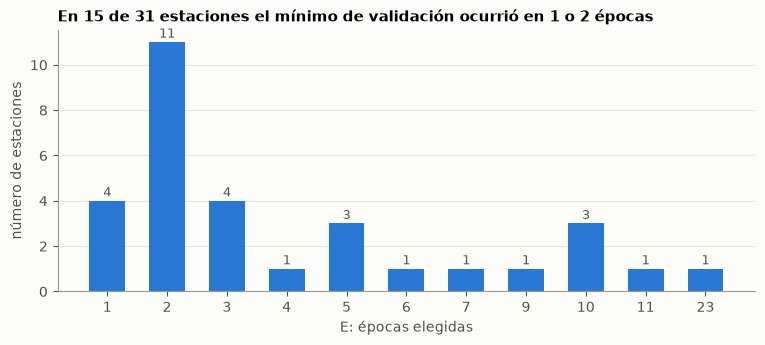

In [9]:
cfgs = pd.DataFrame([json.loads(p.read_text()) for p in sorted(EST.glob('*/configuracion.json'))])
cuenta = cfgs.epoca_E.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(cuenta.index.astype(str), cuenta.values, color=AZUL, width=0.6)
for x, y in zip(cuenta.index.astype(str), cuenta.values):
    ax.text(x, y + 0.2, str(y), ha='center', fontsize=9, color=TINTA2)
ax.set_xlabel('E: épocas elegidas'); ax.set_ylabel('número de estaciones'); ax.grid(axis='x', visible=False)
ax.set_title(f'En {int((cfgs.epoca_E <= 2).sum())} de {len(cfgs)} estaciones el mínimo de validación ocurrió en 1 o 2 épocas', loc='left')
guardar(fig, '07_epocas_E')

Una E pequeña describe dónde estuvo el mínimo en este experimento; no prueba que
toda la información generalizable se aprenda en dos épocas. AJM tiene la E mayor
(23) y escasa cobertura inicial. La coincidencia no demuestra que esa cobertura
sea la causa de su E. No se cambiaron épocas después de observar la prueba.

## 6. Calibración: el umbral de alerta

Con el modelo ya terminado se predijo cada hora de 2023 y se midió el **residuo**
(`lectura − predicción`). El umbral es el **percentil 95** de esos residuos en valor
absoluto: aproximadamente el 95 % de las lecturas de calibración quedan dentro.
Esto no garantiza el mismo porcentaje en otro año.

| | Antes (sólo 2025) | Ahora |
|---|---|---|
| Residuos usados | los del propio entrenamiento (el modelo ya los había visto) | los de 2023 (no vistos) |
| Umbral de CCA | 14.75 ppb (p95) → 22.6 ppb (operativo, elegido después) | 24.16 ppb |
| Umbrales de la red | p95 del entrenamiento de cada estación | 18.9 a 32.5 ppb (mediana 22.4) |

Calibrar sobre el propio ajuste puede producir un umbral optimista, porque los
errores allí no representan necesariamente los de datos nuevos. Aquí se usa un año
separado. La diferencia frente al umbral antiguo no se atribuye a una sola causa:
también cambiaron el modelo entrenado y los datos.

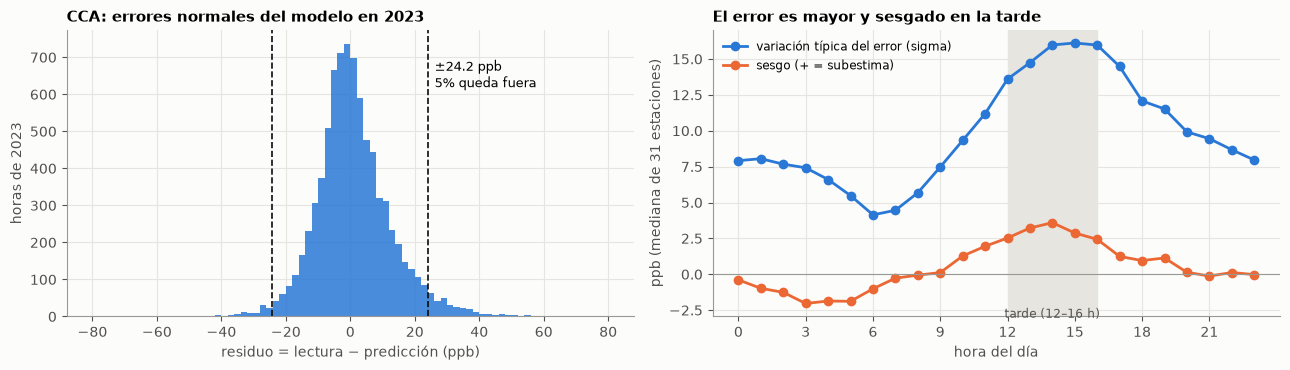

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
ax.hist(cal.residuo_ppb, bins=np.arange(-80, 81, 2), color=AZUL, alpha=0.85)
for s in (-1, 1):
    ax.axvline(s * umbral_cca, color=TINTA, ls='--', lw=1.2)
fuera = (cal.residuo_ppb.abs() > umbral_cca).mean()
ax.text(umbral_cca + 2, ax.get_ylim()[1] * 0.8, f'±{umbral_cca:.1f} ppb\n{fuera:.0%} queda fuera', fontsize=9)
ax.set_xlabel('residuo = lectura − predicción (ppb)'); ax.set_ylabel('horas de 2023')
ax.set_title('CCA: errores normales del modelo en 2023', loc='left')

ax = axes[1]
filas = []
for obj in cfgs.objetivo:
    c = pd.read_csv(EST / obj / 'calibracion_2023.csv.gz', parse_dates=['timestamp'])
    filas.append(c.assign(hora=c.timestamp.dt.hour).groupby('hora').residuo_ppb.agg(['mean', lambda x: x.std(ddof=0)])
                 .set_axis(['sesgo', 'sigma'], axis=1).assign(obj=obj))
porhora = pd.concat(filas).drop(columns='obj').groupby('hora').median()
ax.plot(porhora.index, porhora.sigma, color=AZUL, marker='o', label='variación típica del error (sigma)')
ax.plot(porhora.index, porhora.sesgo, color=NARANJA, marker='o', label='sesgo (+ = subestima)')
ax.axhline(0, color=GRIS, lw=0.8)
ax.axvspan(12, 16, color='#e6e5e0', zorder=0); ax.text(14, porhora.sesgo.min() - 0.3, 'tarde (12–16 h)', ha='center', va='top', fontsize=8.5, color=TINTA2)
ax.set_xticks(range(0, 24, 3)); ax.set_xlabel('hora del día'); ax.set_ylabel('ppb (mediana de 31 estaciones)')
ax.legend(fontsize=8.5, loc='upper left'); ax.set_title('El error es mayor y sesgado en la tarde', loc='left')
fig.tight_layout(); guardar(fig, '08_calibracion')

**Dos lecturas importantes:**

1. El p95 delimita aproximadamente el 95 % de los errores absolutos de calibración.
2. En las horas de tarde mostradas, el error de calibración tiene mayor dispersión
   y sesgo positivo (subestimación). Esto motiva examinar la detección por hora,
   pero no prueba por sí solo dónde se esconde cada ataque. La convención horaria
   del archivo sigue siendo la provisional del protocolo.

## 7. ¿El LSTM sirve más que el perfil?

Una prueba de humildad: si en lugar del LSTM usáramos sólo el perfil de 14 días, ¿qué
error tendríamos? La barra muestra cuánto **reduce** el LSTM el error medio (MAE) en 2023.

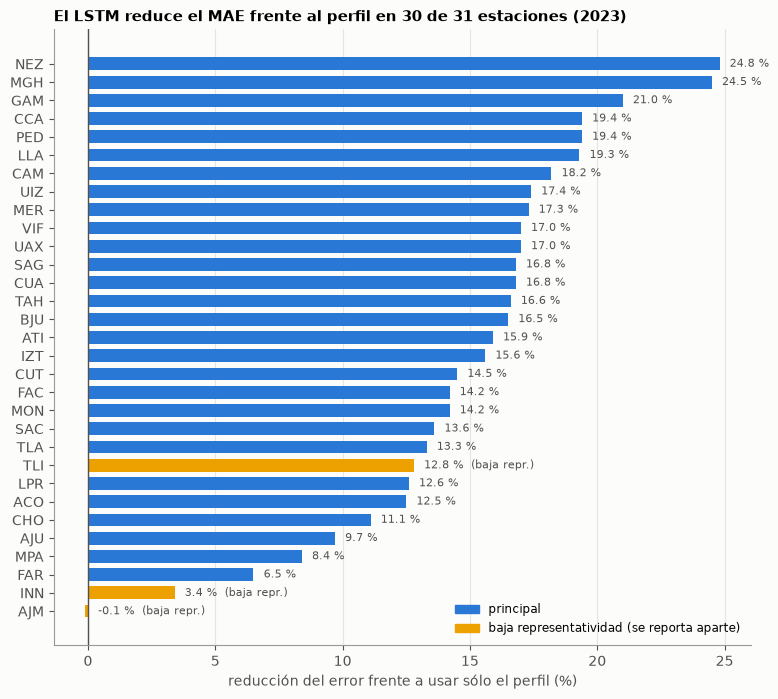

In [11]:
e = estado[estado.entrenado].sort_values('mejora_vs_perfil_pct')
fig, ax = plt.subplots(figsize=(9, 8))
col = [AZUL if c == 'principal' else AMARILLO for c in e.clasificacion]
ax.barh(e.objetivo, e.mejora_vs_perfil_pct, color=col, height=0.7)
for y, (v, c) in enumerate(zip(e.mejora_vs_perfil_pct, e.clasificacion)):
    ax.text(max(v, 0) + 0.4, y, f'{v:.1f} %' + ('  (baja repr.)' if c != 'principal' else ''),
            va='center', fontsize=8, color=TINTA2)
ax.axvline(0, color=TINTA2, lw=1)
ax.set_xlabel('reducción del error frente a usar sólo el perfil (%)'); ax.grid(axis='y', visible=False)
ax.legend(handles=[mpatches.Patch(color=AZUL, label='principal'),
                   mpatches.Patch(color=AMARILLO, label='baja representatividad (se reporta aparte)')],
          loc='lower right', fontsize=8.5)
n_mejor = int((e.mae_cal < e.mae_perfil_cal).sum())
ax.set_title(f'El LSTM reduce el MAE frente al perfil en {n_mejor} de {len(e)} estaciones (2023)', loc='left')
guardar(fig, '09_mejora_vs_perfil')

En calibración 2023, el LSTM mejora el MAE del perfil en **30 de 31 estaciones**;
la mediana de reducción es **15.9 %** (positiva en esta gráfica). AJM no mejora
y ya estaba clasificada como de baja representatividad antes del entrenamiento.
Eso no demuestra que la cobertura sea la única causa de su resultado.

La comprobación en prueba es más importante: mejora al perfil en **26/30 estaciones
en 2024, 30/31 en 2025 y 27/28 en enero–julio de 2026**. Los conteos incluyen los
tres objetivos de baja representatividad; la clasificación se conserva en las tablas.

## 8. Sin ataques: falsas alarmas en años nuevos

En 2023 el umbral daba alerta en el 5 % de las lecturas limpias **por construcción**.
¿Qué pasa en años que el modelo nunca vio? Cada punto es una estación.

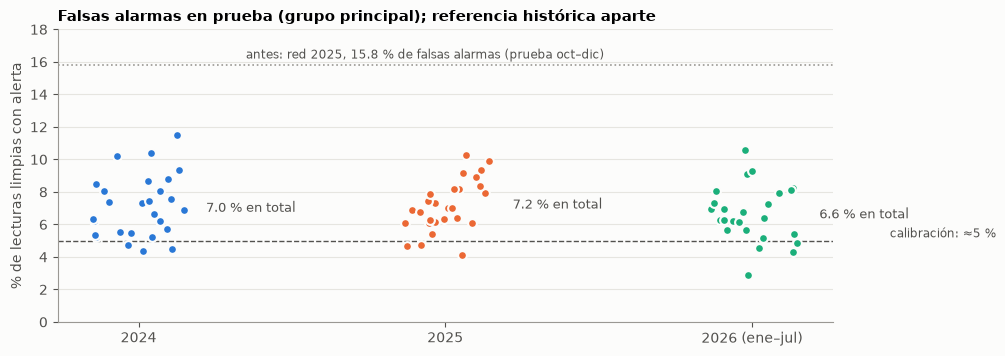

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.8))
rng = np.random.default_rng(0)
for i, anio in enumerate([2024, 2025, 2026]):
    d = limpias[(limpias.anio == anio) & (limpias.clasificacion == 'principal')]
    ax.scatter(i + rng.uniform(-0.15, 0.15, len(d)), 100 * d.fpr, s=40, color=COLOR_ANIO[anio],
               edgecolor='#fcfcfb', linewidth=1.5, zorder=3)
    micro = 100 * d.falsas_alarmas.sum() / d.n.sum()
    ax.text(i + 0.22, micro, f'{micro:.1f} % en total', va='center', fontsize=9, color=TINTA2)
ax.axhline(5, color=TINTA2, ls='--', lw=1); ax.text(2.45, 5.2, 'calibración: ≈5 %', fontsize=8.5, color=TINTA2)
ax.axhline(15.8, color=GRIS, ls=':', lw=1.2)
ax.text(0.35, 16.2, 'antes: red 2025, 15.8 % de falsas alarmas (prueba oct–dic)', fontsize=8.5, color=TINTA2)
ax.set_xticks([0, 1, 2], ['2024', '2025', '2026 (ene–jul)']); ax.set_ylim(0, 18)
ax.set_ylabel('% de lecturas limpias con alerta'); ax.grid(axis='x', visible=False)
ax.set_title('Falsas alarmas en prueba (grupo principal); referencia histórica aparte', loc='left')
guardar(fig, '10_falsas_alarmas')

En el grupo principal la FPR limpia es aproximadamente 7.0 %, 7.2 % y 6.6 %.
Incluyendo también los objetivos de baja representatividad, es **7.06 %, 7.28 %
y 6.57 %** en 2024, 2025 y 2026 parcial, respectivamente. No todas las estaciones
se comportan igual: CHO llega a 11.5 % en 2024.

La referencia anterior tenía 15.8 % en otro periodo y conjunto evaluable. La
diferencia es descriptiva: no aísla el efecto de más años ni de recalibrar. Para
atribuir una mejora se necesitaría un control sobre las mismas lecturas de prueba.
El exceso sobre el ≈5 % de calibración evidencia que ese nivel no se mantuvo;
por sí solo no identifica la causa de la diferencia entre distribuciones.

## 9. Por qué unos bits se detectan y otros no

La figura usa lecturas y predicciones reales de **CCA en calibración 2023**.
Para cada bit se calcula `recibido = original XOR (1 << bit)` y después
`residuo_atacado = recibido − predicho`. Se comprueba el resultado con la cadena
de codificación/cifrado/flip/descifrado usada en los experimentos.

El signo lo determina el bit original, no un sorteo. Las proporciones mostradas
explican el mecanismo en calibración; **no son el recall del test multianual**.
No se modifica el umbral ni ninguna tabla experimental con esta ilustración.

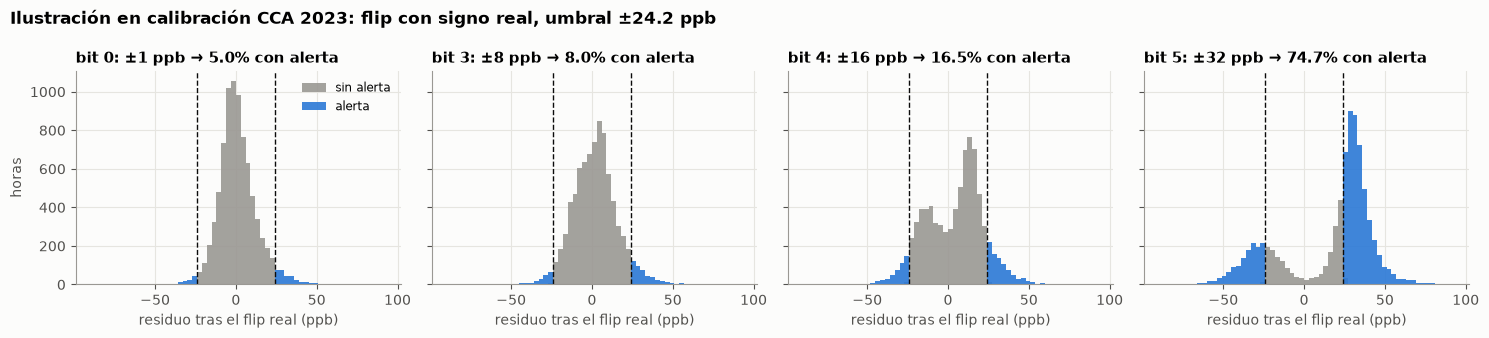

In [13]:
original = cal.original_ppb.to_numpy()
assert np.all(original == np.round(original)), 'O3 debe ser entero para esta codificación'
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for ax, bit in zip(axes, [0, 3, 4, 5]):
    recibido = original.astype(np.int64) ^ (1 << bit)
    np.testing.assert_array_equal(recibido, at.voltear(original, bit))
    d = recibido - cal.predicho_ppb.to_numpy()
    det = np.abs(d) > umbral_cca
    # Mostrar todos los residuos, sin recortar las colas del histograma.
    borde = int(np.ceil(max(90, np.abs(d).max()) / 3) * 3)
    bins = np.arange(-borde, borde + 4, 3)
    ax.hist(d[~det], bins=bins, color=GRIS, alpha=0.9, label='sin alerta')
    ax.hist(d[det], bins=bins, color=AZUL, alpha=0.9, label='alerta')
    for s in (-1, 1):
        ax.axvline(s * umbral_cca, color=TINTA, ls='--', lw=1)
    ax.set_title(f'bit {bit}: ±{2**bit} ppb → {det.mean():.1%} con alerta', loc='left')
    ax.set_xlabel('residuo tras el flip real (ppb)')
axes[0].set_ylabel('horas'); axes[0].legend(fontsize=8.5)
fig.suptitle(f'Ilustración en calibración CCA 2023: flip con signo real, umbral ±{umbral_cca:.1f} ppb',
             x=0.01, ha='left', fontweight='bold')
fig.tight_layout(); guardar(fig, '11_por_que_bits')

- Los desplazamientos pequeños cambian poco el residuo, aunque pueden cruzar un
  umbral de decisión si la lectura estaba cerca de él.
- Con 16 y 32 ppb el signo del flip y el error previo deciden si aparece la alerta.
- En la **prueba**, el bit 6 tiene recall superior al 99 %, pero no perfecto;
  el bit 7 alcanza 100 % en los escenarios evaluables registrados. No se concluye
  que un ataque alto sea imposible de ocultar en cualquier condición futura.

## 10. Resultados contra ataques, antes y ahora

**Muestra pareada al 5 %:** en cada estación se elige al azar 5 % de las lecturas, se
atacan con cada bit (las mismas lecturas para todos los bits) y se cuenta qué porcentaje
de ataques sonó (**recall**). Pero el recall solo engaña: un detector que sonara siempre
tendría 100 %. Por eso se muestra al lado la **tasa de falsas alarmas** (FPR).

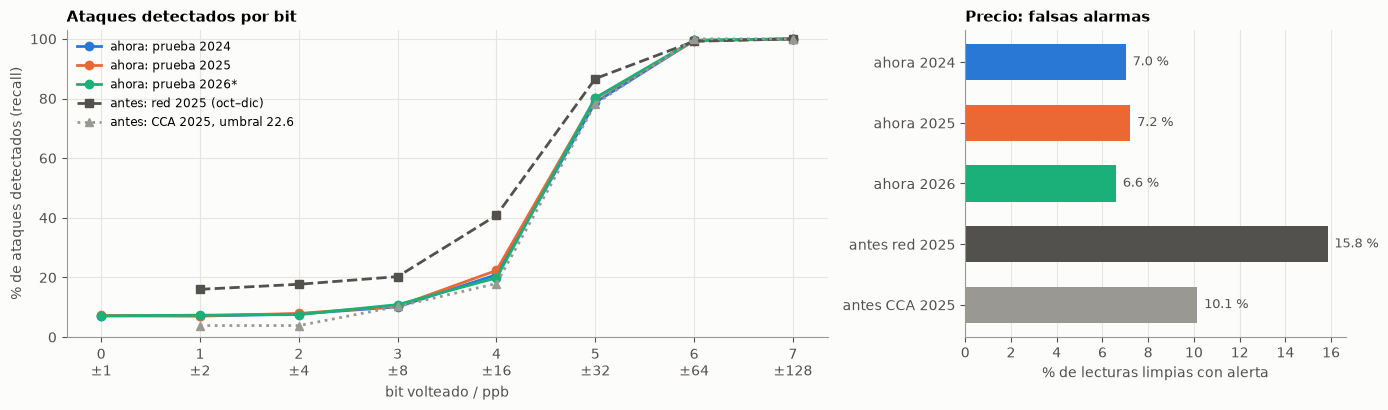

In [14]:
p25 = pd.read_csv(R25 / 'metricas_pareadas.csv').groupby('bit')[['tp', 'fn', 'fp', 'tn']].sum()
p25['recall'] = 100 * p25.tp / (p25.tp + p25.fn); p25['fpr'] = 100 * p25.fp / (p25.fp + p25.tn)
cca25 = pd.read_csv(RAIZ / 'results/metricas_operativas_cca_bits_1_7.csv').set_index('bit')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw=dict(width_ratios=[2, 1]))
ax = axes[0]
for anio in [2024, 2025, 2026]:
    d = pareada[(pareada.anio == anio) & (pareada.grupo == 'principal')]
    ax.plot(d.bit, d.recall_micro_pct, marker='o', color=COLOR_ANIO[anio], label=f'ahora: prueba {anio}' + ('*' if anio == 2026 else ''))
ax.plot(p25.index, p25.recall, marker='s', color=TINTA2, ls='--', label='antes: red 2025 (oct–dic)')
ax.plot(cca25.index, cca25.recall_pct, marker='^', color=GRIS, ls=':', label='antes: CCA 2025, umbral 22.6')
ax.set_xticks(range(8), [f'{b}\n±{2**b}' for b in range(8)]); ax.set_xlabel('bit volteado / ppb')
ax.set_ylabel('% de ataques detectados (recall)'); ax.set_ylim(0, 103); ax.legend(fontsize=8.5, loc='upper left')
ax.set_title('Ataques detectados por bit', loc='left')

ax = axes[1]
fprs = {f'ahora {a}': pareada[(pareada.anio == a) & (pareada.grupo == 'principal')].fpr_micro_pct.iat[0] for a in [2024, 2025, 2026]}
fprs['antes red 2025'] = p25.fpr.iat[0]
fprs['antes CCA 2025'] = cca25.fpr_pct.iat[0]
cols = [AZUL, NARANJA, AQUA, TINTA2, GRIS]
ax.barh(list(fprs)[::-1], list(fprs.values())[::-1], color=cols[::-1], height=0.6)
for y, v in enumerate(list(fprs.values())[::-1]):
    ax.text(v + 0.3, y, f'{v:.1f} %', va='center', fontsize=9, color=TINTA2)
ax.set_xlabel('% de lecturas limpias con alerta'); ax.grid(axis='y', visible=False)
ax.set_title('Precio: falsas alarmas', loc='left')
fig.tight_layout(); guardar(fig, '12_recall_y_fpr')

**Cómo leerlo:** las curvas del grupo principal son parecidas entre años en su
agregado, pero no prueban estabilidad para toda estación ni en cualquier temporada.
2026 sólo cubre enero–julio.

| Año de prueba | Recall bit 4 | Precisión bit 4 | Recall bit 5 | Precisión bit 5 |
|---|---:|---:|---:|---:|
| 2024 | 20.9 % | 13.4 % | 78.7 % | 36.8 % |
| 2025 | 22.3 % | 13.7 % | 80.0 % | 36.3 % |
| 2026, ene–jul | 19.8 % | 13.7 % | 80.2 % | 39.0 % |

Fuente: `metricas_pareadas_agregadas.csv`, grupo **principal**, agregación micro.
La precisión está condicionada a la selección de aproximadamente 5 % de ataques;
no es una garantía operacional con otra prevalencia. Aun con recall alto en bits
6–7, su precisión es aproximadamente 42–44 %: las falsas alarmas siguen importando.

La referencia anterior tenía recall 40.8 % (bit 4), 86.7 % (bit 5) y precisión
21.6 % (bit 5), pero sobre otra prueba. La diferencia observada es compatible con
el compromiso entre sensibilidad y falsas alarmas. **No se ha aislado su causa**:
también cambiaron modelo, periodo, cobertura y umbrales.

En bits 0–2 el recall es cercano a la FPR, lo que indica poca capacidad discriminativa
en este punto de operación. No demuestra que cada alerta concreta hubiera aparecido
sin ataque: para eso hay que comparar ambas decisiones sobre la misma lectura.

## 11. Daño que se escapa: región crítica observada

Daño significa cambiar una decisión. El barrido altera cada lectura con cada bit,
una a la vez, y cuenta días con **al menos una oportunidad de daño sin alerta**.
No representa ataques simultáneos ni la probabilidad de que un atacante ciego
identifique esas oportunidades.

Se recalcula el máximo diario **observado de la red de 33 estaciones**:

- *Cambio de banda de red*: el máximo pasa a otra banda de la función experimental.
- *Excedencia fabricada*: el máximo era <155 y pasa a ≥155 ppb.
- *Excedencia ocultada*: el máximo era ≥155 y pasa a <155 ppb.

No se simula la declaración ni la suspensión oficial de una contingencia.
Las predicciones provienen de todos los modelos evaluables, incluidos los de baja
representatividad. Los escenarios sin predicción se contabilizan **sin evaluación**,
no como detectados ni como escapes comprobados.

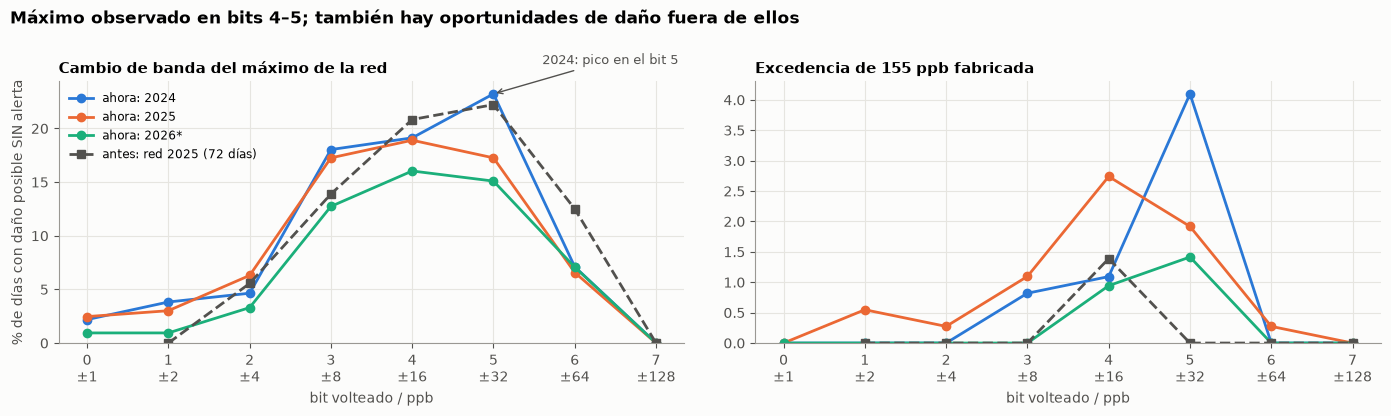

In [15]:
d25 = pd.read_csv(R25 / 'resumen_red_por_bit.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=False)
for ax, tipo, tit in zip(axes, ['cambio_banda_red', 'falsa_fase1'],
                         ['Cambio de banda del máximo de la red', 'Excedencia de 155 ppb fabricada']):
    for anio in [2024, 2025, 2026]:
        g = dias[(dias.anio == anio) & (dias.tipo_dano == tipo)]
        ax.plot(g.bit, g.pct_dias_dano_no_detectado, marker='o', color=COLOR_ANIO[anio],
                label=f'ahora: {anio}' + ('*' if anio == 2026 else ''))
    g = d25[d25.tipo_dano == tipo]
    ax.plot(g.bit, g.pct_dias_dano_no_detectado, marker='s', ls='--', color=TINTA2, label='antes: red 2025 (72 días)')
    ax.set_xticks(range(8), [f'{b}\n±{2**b}' for b in range(8)]); ax.set_xlabel('bit volteado / ppb')
    ax.set_title(tit, loc='left'); ax.set_ylim(bottom=0)
axes[0].set_ylabel('% de días con daño posible SIN alerta'); axes[0].legend(fontsize=8.5)
axes[0].annotate('2024: pico en el bit 5', xy=(5, dias[(dias.anio == 2024) & (dias.tipo_dano == 'cambio_banda_red') & (dias.bit == 5)].pct_dias_dano_no_detectado.iat[0]),
                 xytext=(5.6, 26), fontsize=9, color=TINTA2, arrowprops=dict(arrowstyle='->', color=TINTA2))
fig.suptitle('Máximo observado en bits 4–5; también hay oportunidades de daño fuera de ellos',
             x=0.01, ha='left', fontweight='bold')
fig.tight_layout(); guardar(fig, '13_dano_no_detectado')

Para **cambio de banda del máximo de red**, el máximo de días con oportunidad sin
alerta cae en bit 5 en 2024 y en bit 4 en 2025–2026. Es una región crítica observada
bajo esta métrica y estos datos, no un óptimo universal del adversario.

| Año | Bit 3 | Bit 4 | Bit 5 | Bit 6 | Bit 7 |
|---|---:|---:|---:|---:|---:|
| 2024 (366 días observados) | 66 | 70 | 85 | 26 | 0 |
| 2025 (365 días observados) | 63 | 69 | 63 | 24 | 0 |
| 2026, ene–jul (212 días observados) | 27 | 34 | 32 | 15 | 0 |

Son conteos por bit; no se suman porque pueden compartir fechas. El bit 6 **sí deja
daño sin alerta**, aunque detecta más del 99 % de ataques en la muestra pareada.
Los bits 0–2 tampoco son inocuos: por ejemplo, el bit 0 permite cambio de banda
de red sin alerta en ocho días de 2024. El daño local y el daño de red son distintos.

Para **excedencias fabricadas**, el bit 5 deja oportunidades sin alerta en 15 días
de 2024. El pico de esta otra métrica no tiene por qué coincidir con el de cambio
de banda. La referencia anterior de 72 días no contenía excedencias originales
que ocultar; eso no implica que no pudieran fabricarse excedencias con un ataque.

**Ocultamientos:** mostrar tanto días ocultables / todos los días observados
(frecuencia anual), como días ocultables / días con excedencia original
(vulnerabilidad condicionada). Responden preguntas distintas y ambos denominadores
son válidos si se explican. La siguiente figura usa el segundo contexto.

      dias_con_excedencia  ocultables  ocultables_sin_alerta  ocultables_sin_detector  pct_sin_alerta
anio                                                                                                 
2024                   17           3                      2                        1            11.8
2025                    6           3                      2                        0            33.3
2026                    9           2                      0                        0             0.0


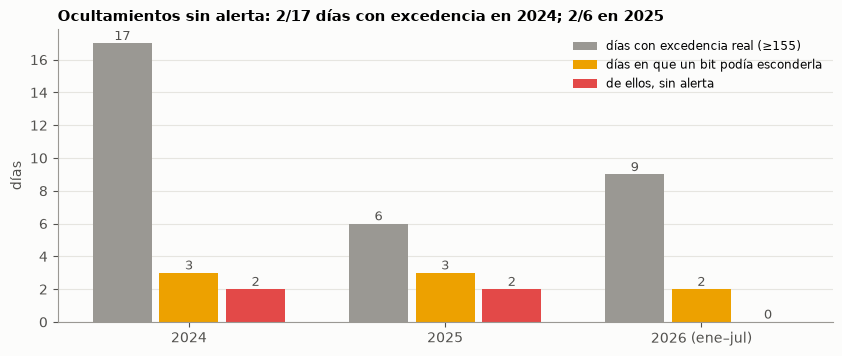

In [16]:
filas = []
for anio in [2024, 2025, 2026]:
    ev = pd.read_parquet(SAL / f'eventos_dano/eventos_{anio}.parquet') if (SAL / f'eventos_dano/eventos_{anio}.parquet').exists() else None
    exc = int(dias[(dias.anio == anio)].dias_con_excedencia_original.iat[0])
    if ev is None:
        print(f'{anio}: falta eventos_dano/ (ejecuta el notebook 13 con CALCULAR = True)'); continue
    an = ev[ev.anulada_fase1]
    filas.append(dict(anio=anio, dias_con_excedencia=exc, ocultables=an.fecha.nunique(),
                      ocultables_sin_alerta=an[an.evaluable & ~an.detectado].fecha.nunique(),
                      ocultables_sin_detector=an[~an.evaluable].fecha.nunique()))
desact = pd.DataFrame(filas).set_index('anio')
desact['pct_sin_alerta'] = (100 * desact.ocultables_sin_alerta / desact.dias_con_excedencia).round(1)
print(desact.to_string())

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(desact)); w = 0.26
for k, (col, color, lab) in enumerate([('dias_con_excedencia', GRIS, 'días con excedencia real (≥155)'),
                                       ('ocultables', AMARILLO, 'días en que un bit podía esconderla'),
                                       ('ocultables_sin_alerta', CRITICO, 'de ellos, sin alerta')]):
    ax.bar(x + (k - 1) * w, desact[col], width=w - 0.03, color=color, label=lab)
    for xi, v in zip(x, desact[col]):
        ax.text(xi + (k - 1) * w, v + 0.2, str(v), ha='center', fontsize=9, color=TINTA2)
ax.set_xticks(x, [f'{a}' + (' (ene–jul)' if a == 2026 else '') for a in desact.index])
ax.set_ylabel('días'); ax.grid(axis='x', visible=False); ax.legend(fontsize=8.5, loc='upper right')
ax.set_title('Ocultamientos sin alerta: 2/17 días con excedencia en 2024; 2/6 en 2025', loc='left')
guardar(fig, '13b_desactivaciones')

- Se identificaron **dos días ocultables sin alerta de 17 con excedencia en 2024
  (11.8 %), dos de seis en 2025 (33.3 %) y ninguno de nueve en 2026 parcial**.
  Son oportunidades observadas con un mensaje; no tasas de éxito de una campaña
  ni contingencias oficiales anuladas. Los denominadores son pequeños.
- En los cuatro casos sin alerta sólo una lectura del día era ≥155; la siguiente
  más alta quedaba en 151–153 ppb. Si queda otra lectura ≥155, bajar una no basta.
- Los eventos concretos fueron CCA el 6/may/2024 (bit 4), UAX el 25/may/2024,
  AJM el 19/mar/2025 y UAX el 23/abr/2025 (estos tres con bit 5).
- El cero de 2026 significa que no apareció un ocultamiento sin alerta **en esta
  evaluación**; no demuestra protección universal.

**Ejemplo real: un ataque puede acercarse a lo que esperaba el detector.**

| CCA, 6/may/2024 | Sin ataque | Con flip del bit 4 |
|---|---:|---:|
| Lectura del mensaje | 156 ppb | 140 ppb |
| Predicción guardada | 121.15 ppb | 121.15 ppb |
| Error absoluto | 34.85 ppb | 18.85 ppb |
| Umbral del detector | 24.16 ppb | 24.16 ppb |
| ¿Alerta? | Sí, falsa alarma sobre lectura limpia | No |
| Máximo diario de red | 156 ppb | 153 ppb |

La lectura falsa se aproxima a la predicción y el máximo queda por debajo de 155.
El ejemplo muestra una debilidad concreta; no supone que el atacante conozca la
lectura ni que el receptor tenga acceso al original para corregirla.

El test antiguo del LSTM no podía medir ocultamientos por falta de excedencias;
el análisis anual sin LSTM del notebook 08 **sí los había estudiado**. El aporte
nuevo es evaluar esos escenarios junto con el detector fuera de su ajuste.

## 12. Las estaciones sin detector

HGM y XAL no tienen modelo propio bajo este protocolo. Sus lecturas siguen
participando en el máximo observado, pero no reciben una decisión de este LSTM.
No se afirma que carezcan de cualquier protección en el sistema real.

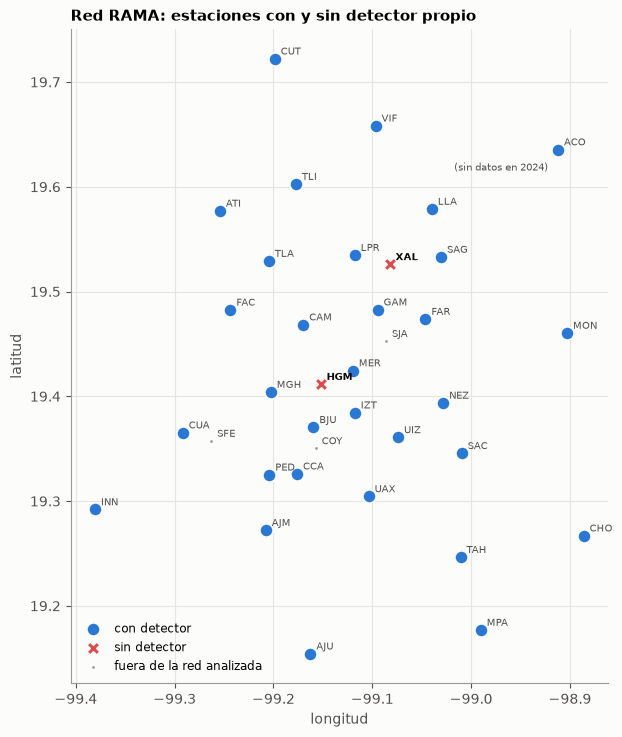

In [17]:
sin = {'HGM', 'XAL'}
g = geo.copy()
g['estado'] = np.where(g.index.isin(sin), 'sin detector',
                       np.where(g.en_matriz_2025, 'con detector', 'fuera de la red analizada'))
fig, ax = plt.subplots(figsize=(8, 8.5))
for est_, color, marker in [('con detector', AZUL, 'o'), ('sin detector', CRITICO, 'X'), ('fuera de la red analizada', GRIS, '.')]:
    d = g[g.estado == est_]
    ax.scatter(d.longitud, d.latitud, s=90 if marker != '.' else 40, color=color, marker=marker,
               edgecolor='#fcfcfb', linewidth=1.2, label=est_, zorder=3)
for s, rr in g.iterrows():
    ax.text(rr.longitud + 0.006, rr.latitud + 0.004, s, fontsize=7.5, color=TINTA if s in sin else TINTA2,
            weight='bold' if s in sin else 'normal')
ax.text(g.loc['ACO', 'longitud'] - 0.01, g.loc['ACO', 'latitud'] - 0.02, '(sin datos en 2024)', fontsize=7, color=TINTA2, ha='right')
ax.set_aspect(1 / np.cos(np.radians(19.4))); ax.set_xlabel('longitud'); ax.set_ylabel('latitud')
ax.legend(fontsize=8.5, loc='lower left')
ax.set_title('Red RAMA: estaciones con y sin detector propio', loc='left')
guardar(fig, '14_mapa_detectores')

En el barrido registrado, el bit 7 (±128 ppb) se detecta en todos los escenarios
**evaluables**. Por otra parte, ataques a lecturas de **HGM o XAL** permiten fabricar
una excedencia en 306 de los 366 días de 2024, sin evaluación del detector propio.
Estos días no se suman a los escapes comprobados: expresan cobertura incompleta.

**ACO sí tiene detector**, pero no lecturas en 2024; por tanto, no origina ninguno
de esos escenarios ese año. Cubrir HGM/XAL exige un experimento separado.

## 13. Resumen final y cierre

| Pregunta | Resultado que sí respaldan los artefactos |
|---|---|
| ¿Qué se entrenó? | 31 LSTM V4, ajuste definitivo 2020–2022; umbral propio calibrado en 2023 |
| ¿Qué se probó? | 2024 y 2025 completos, enero–julio de 2026; 30/31/28 estaciones evaluables |
| ¿Sigue siendo V4? | Misma arquitectura y esquema 24 h × 66 + perfil de 14 días; protocolo temporal y respaldo causal nuevos |
| ¿Aporta frente al perfil solo? | En prueba reduce MAE en 26/30, 30/31 y 27/28 estaciones, respectivamente |
| ¿Cuántas falsas alarmas? | 7.06 %, 7.28 %, 6.57 % sobre todas las lecturas limpias evaluables; no idéntico por estación |
| ¿Dónde está el máximo de daño diario sin alerta? | Cambio de banda de red: bit 5 en 2024, bit 4 en 2025 y 2026 |
| ¿Los bits altos son perfectos? | Bit 6 deja daño sin alerta; bit 7 tuvo detección completa en los escenarios evaluables registrados |
| ¿Se pueden ocultar excedencias? | Sin alerta en 2/17, 2/6 y 0/9 días con excedencia original; no son contingencias oficiales |
| ¿Qué falta cubrir? | HGM/XAL sin detector propio; 2026 parcial; incertidumbre con pocos eventos |
| ¿Qué reproducibilidad se verificó? | Reentrenamiento en CCA y TLI, y repetición de la evaluación; no reentrenamiento duplicado de los 31 modelos |

**Conclusión:** esta referencia amplía la evaluación a temporadas con excedencias
y permite medir oportunidades de ocultamiento junto con la detección. En el
escenario de un mensaje, los máximos de daño diario sin alerta se ubican en bits
4–5 para cambio de banda de red, sin que los demás bits sean necesariamente inocuos.
El predictor mejora el MAE del perfil en la mayoría de las estaciones, pero las
falsas alarmas y el daño que escapa siguen limitando su uso.

**No se concluye** que más años sean la causa de una mejora, que la calibración
explique por sí sola la diferencia histórica, que el modelo conozca geografía,
ni que un cruce del máximo diario equivalga a activar o suspender una contingencia.
La precisión depende de la prevalencia de ataques y la comparación histórica usa
otro periodo; no es una competición controlada entre modelos.

La **distribución B** queda como resultado negativo separado: en las campañas
evaluadas con los detectores antiguos, los cambios de banda local sin alerta
pasaron de 255 (Base) a 567 (B). No se reevalúa B con el multianual ni se generaliza
ese resultado a cualquier codificación. Ver `experiments/cayenne_mod/avance_junta_11.md`.

**Siguiente:** analizar la aportación de estaciones y su relación con la distancia;
después comparar con CNN-1D bajo el mismo protocolo. Mantener la redacción de la
tesis en paralelo. No ajustar los modelos actuales para mejorar estas tablas.

Fuentes: `estado_objetivos.csv`, `metricas_limpias.csv`,
`metricas_pareadas_agregadas.csv`, `resumen_dano_dias.csv` y el detalle de
`eventos_dano/`, dentro de `results/lstm_v4_multianual_v1/`.
Figuras: `docs/img/lstm_v4_multianual_v1/resumen/`.